**Data Extraction and Spatial Aggregation via Google Earth Engine**
To build a continental-scale historical dataset of drought frequency and intensity, historical soil moisture data (Standardized Soil Moisture Index, SSI) was extracted from the ERA5-Land reanalysis dataset using the Google Earth Engine (GEE) Python API. A critical methodological step in this extraction pipeline is the transition from pixel-level, continuous gridded hazard data to discrete, administrative-level risk indicators representing the ~3,500 maize-growing districts across Africa.

To achieve this, a spatial mean reducer was applied to calculate the average daily soil moisture across all pixels intersecting each individual district. This methodological choice is supported by several key considerations inherent to parametric insurance design and geospatial analysis:

**1. Alignment with Parametric Insurance Mechanics**
In agricultural index insurance, financial payouts are triggered by the collective conditions experienced within a predefined geographical zone (e.g., a district or county). Shruthi et al. (2025) highlight that aggregating satellite-derived indices to the specific insurance unit is an established industry standard required to minimize localized, idiosyncratic noise and accurately capture the systemic climatic risks necessary for scaling parametric portfolios. The spatial mean effectively represents the "average experience" of a maize farmer within that district.

**2. Mitigating Coarse Spatial Resolution**
Given the relatively coarse spatial resolution of ERA5 reanalysis data (~9 km), pixel-level extraction without aggregation is highly susceptible to localized anomalies. A single pixel might overlap with a river, a localized wetland, or an urban center, skewing the environmental reality of the surrounding agricultural land. Applying a spatial mean mathematically smooths these anomalies, ensuring that outlier pixels do not distort the broader district's water budget (Beltran-Peña & Diaz, 2023; Gumiere et al., 2025).

**3. Standardization in Remote Sensing Literature**
For continuous environmental variables like soil moisture, employing a spatial mean (often referred to as zonal statistics) is the recognized standard in remote sensing literature. Recent studies utilizing GEE for regional drought propagation and soil moisture monitoring explicitly rely on spatial mean reductions across administrative boundaries to generate reliable historical time-series data (Ruhoff et al., 2023; NASA DEVELOP National Program, 2024).

**4. Rejection of Alternative Mathematical Reducers**
Alternative aggregation methods, such as the minimum, maximum, or sum, were evaluated but explicitly rejected due to their potential to critically compromise the integrity of the risk model:

* Minimum: Extracting the single driest pixel would heavily exaggerate drought risk. In an insurance context, this would trigger constant false-positive payouts (paying when no widespread agricultural loss occurred), bankrupting the insurance portfolio.
* Maximum: Extracting the wettest pixel would artificially mask systemic drought risk. If a widespread drought occurs but one pixel registers high moisture (e.g., over a lake or irrigated land), the index would fail to trigger, resulting in severe basis risk and leaving farmers unprotected.
* Spatial Sum: While temporal sums are useful, a spatial sum of soil moisture percentages across a district is physically meaningless and cannot be used to assess biological crop stress.

**Establishing the Baseline for Temporal Analysis**
By generating a reliable, singular daily mean for each district, this extraction methodology establishes a scientifically valid baseline. As per the study’s framework, these continuous daily averages are required to perform subsequent temporal aggregations over the designated risk period (January 1st to April 30th). With a clean daily mean established per district, the data can be further processed to calculate the temporal sum of soil moisture or calculate the exact number of days a district falls below an extreme drought threshold (e.g., SSI ≤ -1.2), providing the foundation for the spatial clustering and portfolio diversification phases of this research.

In [99]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [100]:
# ---------------------------------------------------------
# 1. LOAD DATA & FORMAT DATE COLUMN
# ---------------------------------------------------------
# Replace 'your_downloaded_data.csv' with your actual file name
df = pd.read_csv(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Files\ERA5_LAND_DAILY_AGGR_2000_2026_timeseries.csv")

In [101]:
df.head()

,system:index,date,year,month,day,doy,feature_id,source,volumetric_soil_water_layer_2,system_time
0,20000101_0,2000-01-01,2000,1,1,1,ZIMBA,shapefile,0.303405,9.466848e+11
1,20000101_1,2000-01-01,2000,1,1,1,SINDA,shapefile,0.303973,9.466848e+11
2,20000101_2,2000-01-01,2000,1,1,1,CHADIZA,shapefile,0.265190,9.466848e+11
3,20000101_3,2000-01-01,2000,1,1,1,VUBWI,shapefile,0.223065,9.466848e+11
4,20000101_4,2000-01-01,2000,1,1,1,SINAZONGWE,shapefile,0.191339,9.466848e+11


In [102]:
# Look at your data to ensure column names match. 
# We assume you have columns named: 'Date', 'District', and 'SSI'
# If your columns are named differently, change them below.

# Convert the Date column to a proper datetime format
#df['date'] = pd.to_datetime(df['date'])

# Extract Year and Month into separate columns for easy filtering and grouping
#df['Year'] = df['date'].dt.year
#df['Month'] = df['date'].dt.month

In [103]:
# ---------------------------------------------------------
# 2. EXTRACT EXACTLY JAN TO APRIL (THE "RISK PERIOD")
# ---------------------------------------------------------
# Your boss said: "sum from 1st of January to 30th of April"
# So we filter for Month >= 1 (Jan) and Month <= 4 (April)
df_risk_period = df[(df['month'] >= 1) & (df['month'] <= 4)].copy()

In [104]:
print(df.columns)
print(climatology.columns)

Index(['system:index', 'date', 'year', 'month', 'day', 'doy', 'feature_id',
       'source', 'volumetric_soil_water_layer_2', 'system_time'],
      dtype='object')
Index(['feature_id', 'doy', 'Historical_Mean', 'Historical_Std'], dtype='object')


To calculate the Standardized Soil Moisture Index (SSI), a daily climatological baseline (Day of Year, DOY 1-365) was established rather than a traditional monthly baseline. Recent advancements in agricultural drought monitoring emphasize that monthly-resolution indices are often too coarse to capture rapid-onset water deficits, commonly known as flash droughts, which can cause severe crop damage within a matter of weeks (Wang et al., 2024). Furthermore, utilizing a monthly baseline for continuous daily data introduces artificial step-changes at calendar-month boundaries, skewing anomaly detection (Stagge et al., 2025). By standardizing the daily volumetric soil moisture against its specific Julian day historical mean and standard deviation, the resulting daily SSI provides a continuous, high-resolution metric. This methodology aligns with recent frameworks for sub-seasonal ecological monitoring, ensuring that short-term, critical water stress during sensitive crop phenological stages is accurately captured (Lipponen et al., 2023).

In [105]:
# 2. CALCULATE THE SSI (STANDARDIZED SOIL MOISTURE INDEX)
# ---------------------------------------------------------
# Step A: Calculate the 25-year historical mean and standard dev for EACH district on EACH day of the year
# Step A: climatology
climatology = (
    df.groupby(['feature_id', 'doy'])['volumetric_soil_water_layer_2']
    .agg(Historical_Mean='mean', Historical_Std='std')
    .reset_index()
)

# Step B: merge
df = df.merge(climatology, on=['feature_id', 'doy'], how='left')

# Step C: calculate SSI
df['SSI'] = (
    df['volumetric_soil_water_layer_2'] - df['Historical_Mean']
) / (df['Historical_Std'] + 1e-6)

print(df[['date', 'feature_id', 'volumetric_soil_water_layer_2', 'Historical_Mean', 'SSI']].head())

         date  feature_id  volumetric_soil_water_layer_2  Historical_Mean  \
0  2000-01-01       ZIMBA                       0.303405         0.390155   
1  2000-01-01       SINDA                       0.303973         0.451094   
2  2000-01-01     CHADIZA                       0.265190         0.434681   
3  2000-01-01       VUBWI                       0.223065         0.401271   
4  2000-01-01  SINAZONGWE                       0.191339         0.293925   

        SSI  
0 -1.377918  
1 -2.682711  
2 -3.332624  
3 -3.164414  
4 -1.769121  


In [106]:
# ---------------------------------------------------------
# 3. EXTRACT EXACTLY JAN TO APRIL (THE "RISK PERIOD")
# ---------------------------------------------------------
df_risk_period = df[(df['month'] >= 1) & (df['month'] <= 4)].copy()

The yearly aggregation of SSI was undertaken to summarise both the cumulative severity and the persistence of drought conditions during the January–April risk period. Specifically, the sum of SSI values by district and year provides an indicator of overall moisture deficit intensity, with more negative totals reflecting stronger and more sustained dry conditions. In addition, the number of days with SSI values at =< −1.5 was calculated to quantify the frequency of extreme drought exposure, since standardized drought values below this threshold are commonly interpreted as severe drought conditions (Carrão et al., 2016; Lipponen et al., 2023). Combining these two metrics provides a more complete representation of drought risk than using a single index alone, because agricultural impacts depend on both the magnitude and duration of moisture stress (Wang et al., 2022). The final merged dataset was then exported for mapping and comparison across districts and years.

In [107]:
# ---------------------------------------------------------
# 4. CALCULATE THE TWO INDICES (Sum and Extreme Drought Count)
# ---------------------------------------------------------
# Calculate Index 1: The Sum of SSI per year, per district
ssi_sum = df_risk_period.groupby(['feature_id', 'year'])['SSI'].sum().reset_index(name='Sum_SSI')

# Calculate Index 2: Count of days below -1.5 (Extreme Drought)
df_risk_period['Is_Extreme_Drought'] = (df_risk_period['SSI'] <= -1.5).astype(int)
drought_days_count = df_risk_period.groupby(['feature_id', 'year'])['Is_Extreme_Drought'].sum().reset_index(name='Count_Extreme_Drought_Days')

# Merge the two indices into one final, clean DataFrame for plotting
df_yearly_summary = pd.merge(ssi_sum, drought_days_count, on=['feature_id', 'year'])

# Save your final data!
df_yearly_summary.to_csv('Zambia_District_SSI_Jan-Apr_2000-2024.csv', index=False)

To calculate the Standardized Soil Moisture Index (SSI), a daily climatological baseline based on Day of Year (DOY 1–365) was used rather than a monthly baseline. This approach is methodologically appropriate because daily soil-moisture standardization is more suitable for capturing rapid fluctuations in water availability and short-duration drought events than monthly aggregation, which may obscure the onset and progression of flash drought conditions (Carrão et al., 2016; Wang et al., 2022). By standardizing daily volumetric soil moisture against the corresponding long-term historical mean and standard deviation for each Julian day, the SSI provides a continuous and temporally sensitive measure of moisture anomaly. This allows short-term agricultural stress to be represented more accurately, particularly during critical crop growth stages (Carrão et al., 2016; Lipponen et al., 2023). The use of a daily baseline is therefore consistent with recent advances in hydrometeorological drought monitoring that emphasize high-resolution, daily-scale indices for improved environmental and agricultural assessment (Wang et al., 2022; Lipponen et al., 2023).

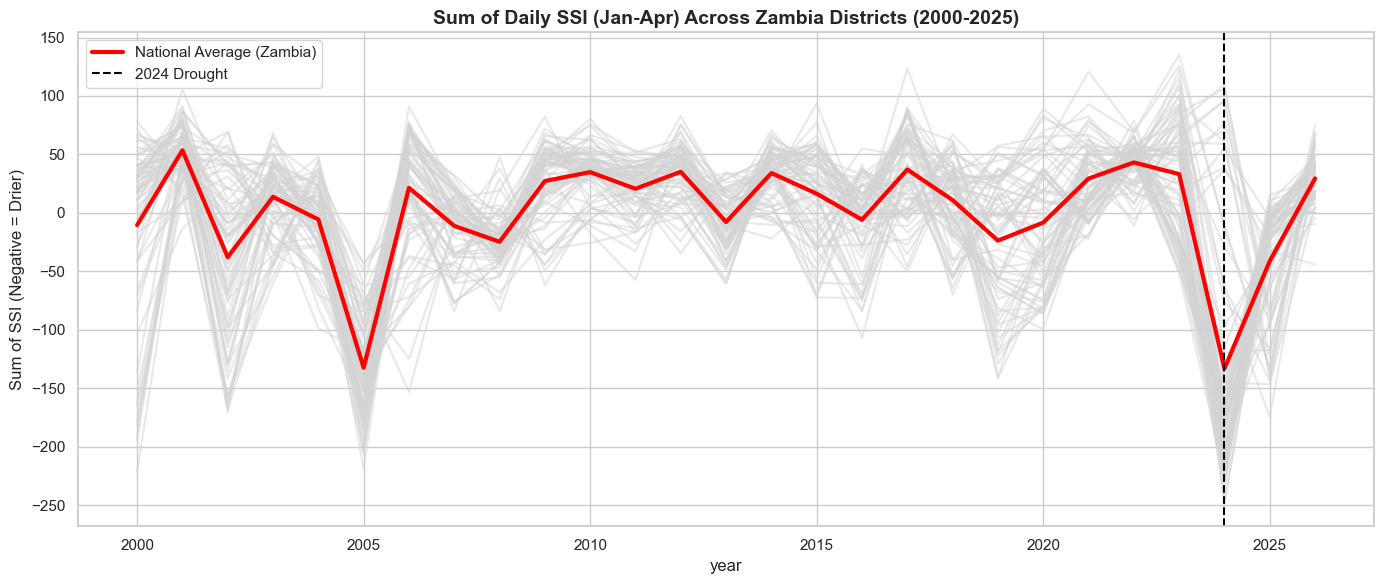

In [108]:
# ---------------------------------------------------------
# 5. PLOTTING THE DATA TO SHOW THE "2024 DROP"
# ---------------------------------------------------------
sns.set_theme(style="whitegrid")

# --- PLOT 1: Sum of SSI (Time Series) ---
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_yearly_summary, 
    x='year', 
    y='Sum_SSI', 
    hue='feature_id', 
    palette=['lightgray'] * len(df_yearly_summary['feature_id'].unique()), 
    legend=False, 
    alpha=0.5
)

# Plot the national average trend as a thick red line
sns.lineplot(
    data=df_yearly_summary, 
    x='year', 
    y='Sum_SSI', 
    color='red', 
    linewidth=3, 
    label='National Average (Zambia)',
    errorbar=None
)

plt.title('Sum of Daily SSI (Jan-Apr) Across Zambia Districts (2000-2025)', fontsize=14, fontweight='bold')
plt.xlabel('year', fontsize=12)
plt.ylabel('Sum of SSI (Negative = Drier)', fontsize=12)
plt.axvline(x=2024, color='black', linestyle='--', label='2024 Drought')
plt.legend()
plt.tight_layout()
plt.savefig('Sum of Daily SSI (Jan-Apr) Across Zambia Districts.jpg', dpi=300, bbox_inches='tight', format='jpg')

plt.show()

The annual number of extreme drought days was calculated by counting the days on which SSI was =<−1.5 for each district during the January–April risk period. This threshold was selected to represent severe drought conditions, consistent with standardized drought classification frameworks in which more negative values correspond to increasing drought severity (Copernicus JRC, n.d.; Carrão et al., 2016). The resulting metric captures drought frequency and persistence, both of which are critical for understanding agricultural impact because crop responses depend not only on the magnitude of soil-moisture deficit but also on the duration of exposure to water stress (Wang et al., 2022; Lipponen et al., 2023). By summarising daily SSI values into annual extreme drought-day counts, the analysis provides a clearer comparison of drought persistence across districts and years, including the 2024 event, and supports the identification of areas experiencing prolonged severe moisture stress.

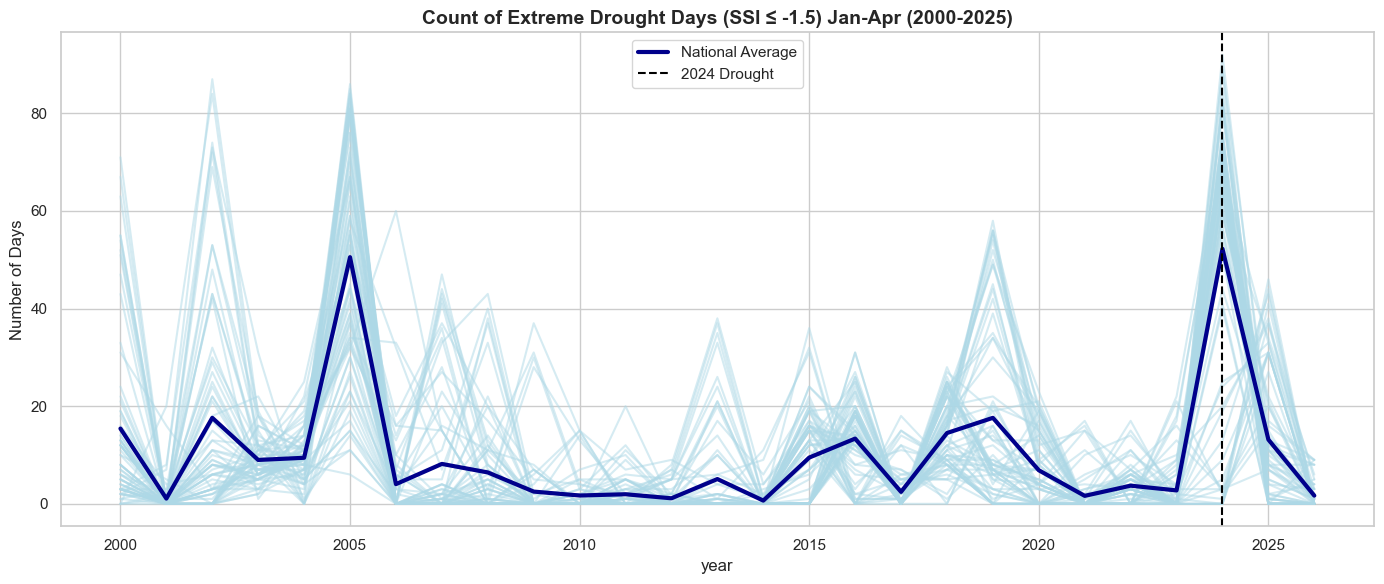

In [109]:
# --- PLOT 2: Count of Extreme Drought Days ---
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=df_yearly_summary, 
    x='year', 
    y='Count_Extreme_Drought_Days', 
    hue='feature_id', 
    palette=['lightblue'] * len(df_yearly_summary['feature_id'].unique()), 
    legend=False, 
    alpha=0.5
)

sns.lineplot(
    data=df_yearly_summary, 
    x='year', 
    y='Count_Extreme_Drought_Days', 
    color='darkblue', 
    linewidth=3, 
    label='National Average',
    errorbar=None
)

plt.title('Count of Extreme Drought Days (SSI ≤ -1.5) Jan-Apr (2000-2025)', fontsize=14, fontweight='bold')
plt.xlabel('year', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)
plt.axvline(x=2024, color='black', linestyle='--', label='2024 Drought')
plt.legend()
plt.tight_layout()
plt.savefig('Count of Extreme Drought Days.jpg', dpi=300, bbox_inches='tight', format='jpg')
plt.show()

In [110]:
import geopandas as gpd
import matplotlib.pyplot as plt

# replace with your actual file path
gdf = gpd.read_file(r"C:\Users\flavi\OneDrive - Africa Specialty Risks Ltd\ASR-Parametric_Research_Study\africa_risk\Drought\Output\Zambia\Output\Zambia_agri_districts.shp")

# check what loaded
print(gdf.head())
print(gdf.columns)
print(gdf.crs)

  ISO3 ISO3_y COUNTRY    ADM_NAME     crop_km2    total_km2   crop_pct  \
0  ZMB    ZMB  Zambia       Zimba   949.098145  5265.908972  18.023444   
1  ZMB    ZMB  Zambia       Sinda  1451.961261  2599.115619  55.863666   
2  ZMB    ZMB  Zambia     Chadiza   614.591514  1511.995598  40.647705   
3  ZMB    ZMB  Zambia       Vubwi   252.849453   923.996320  27.364768   
4  ZMB    ZMB  Zambia  Sinazongwe   508.571774  5087.551660   9.996395   

    cum_pct                                           geometry  
0  0.488603  POLYGON ((26.96784 -17.34588, 26.96954 -17.348...  
1  0.293770  POLYGON ((32.07812 -14.37042, 32.06732 -14.374...  
2  0.625570  POLYGON ((32.65424 -14.19048, 32.64394 -14.194...  
3  0.848091  POLYGON ((32.87944 -13.80558, 32.88634 -13.809...  
4  0.666256  POLYGON ((27.06074 -17.52768, 27.06534 -17.516...  
Index(['ISO3', 'ISO3_y', 'COUNTRY', 'ADM_NAME', 'crop_km2', 'total_km2',
       'crop_pct', 'cum_pct', 'geometry'],
      dtype='object')
EPSG:4326


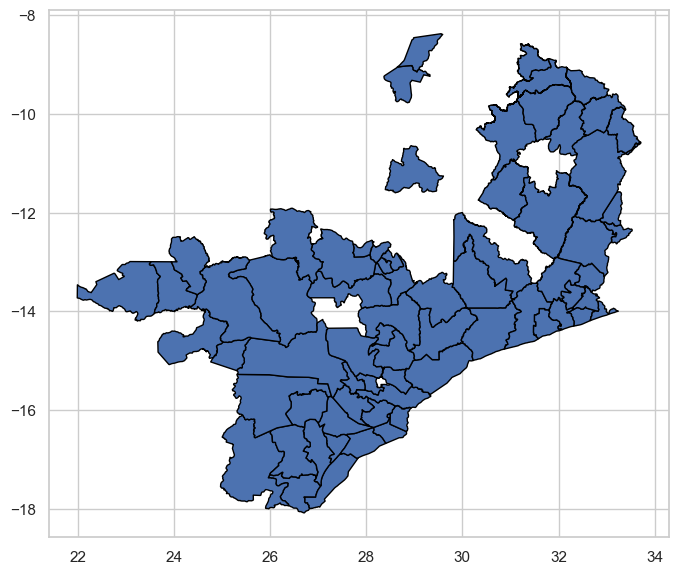

In [111]:
#Quick preview
gdf.plot(figsize=(8, 8), edgecolor="black")
plt.show()

In [112]:
# Check district names
print(gdf[['ADM_NAME']].head())
print(df_yearly_summary[['feature_id']].drop_duplicates().head())

# Standardize text to avoid merge problems
gdf['ADM_NAME'] = gdf['ADM_NAME'].str.strip().str.upper()
df_yearly_summary['feature_id'] = df_yearly_summary['feature_id'].str.strip().str.upper()

# Merge one year, for example 2024
gdf_2024 = gdf.merge(
    df_yearly_summary[df_yearly_summary['year'] == 2024],
    left_on='ADM_NAME',
    right_on='feature_id',
    how='left'
)

print(gdf_2024.head())

     ADM_NAME
0       Zimba
1       Sinda
2     Chadiza
3       Vubwi
4  Sinazongwe
    feature_id
0      CHADIZA
27       CHAMA
54     CHASEFU
81    CHIBOMBO
108    CHIENGI
  ISO3 ISO3_y COUNTRY    ADM_NAME     crop_km2    total_km2   crop_pct  \
0  ZMB    ZMB  Zambia       ZIMBA   949.098145  5265.908972  18.023444   
1  ZMB    ZMB  Zambia       SINDA  1451.961261  2599.115619  55.863666   
2  ZMB    ZMB  Zambia     CHADIZA   614.591514  1511.995598  40.647705   
3  ZMB    ZMB  Zambia       VUBWI   252.849453   923.996320  27.364768   
4  ZMB    ZMB  Zambia  SINAZONGWE   508.571774  5087.551660   9.996395   

    cum_pct                                           geometry  feature_id  \
0  0.488603  POLYGON ((26.96784 -17.34588, 26.96954 -17.348...       ZIMBA   
1  0.293770  POLYGON ((32.07812 -14.37042, 32.06732 -14.374...       SINDA   
2  0.625570  POLYGON ((32.65424 -14.19048, 32.64394 -14.194...     CHADIZA   
3  0.848091  POLYGON ((32.87944 -13.80558, 32.88634 -13.809...       

In [113]:
gdf['ADM_NAME'].nunique()
# gdf['ADM_NAME'].unique()


70

In [114]:
gdf_proj = gdf.to_crs(epsg=3857)

C:\Users\flavi\AppData\Local\Temp\ipykernel_33592\2613913951.py:101: UserWarning:

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.



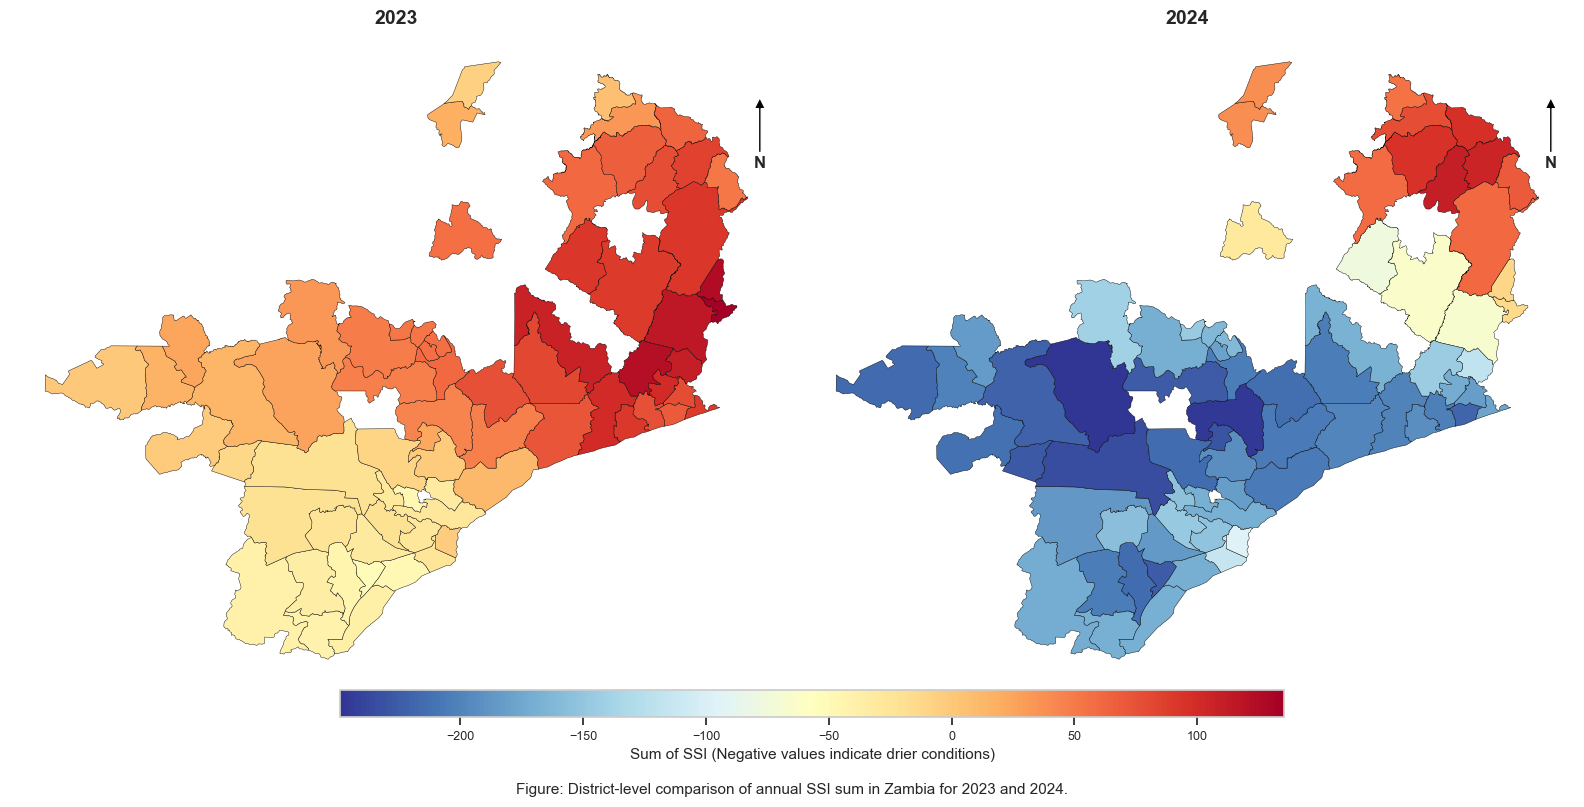

In [115]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib as mpl

# -----------------------------
# 1. Clean names
# -----------------------------
gdf['ADM_NAME'] = gdf['ADM_NAME'].astype(str).str.strip().str.upper()
df_yearly_summary['feature_id'] = df_yearly_summary['feature_id'].astype(str).str.strip().str.upper()

# -----------------------------
# 2. Filter years
# -----------------------------
df_two_years = df_yearly_summary[df_yearly_summary['year'].isin([2023, 2024])].copy()

# -----------------------------
# 3. Merge
# -----------------------------
gdf_map = gdf.merge(
    df_two_years,
    left_on='ADM_NAME',
    right_on='feature_id',
    how='left'
)

# -----------------------------
# 4. Common color scale
# -----------------------------
vmin = df_two_years['Sum_SSI'].min()
vmax = df_two_years['Sum_SSI'].max()
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.RdYlBu_r

# -----------------------------
# 5. Plot maps
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

for ax, yr in zip(axes, [2023, 2024]):
    gdf_yr = gdf_map[gdf_map['year'] == yr].copy()

    gdf_yr.plot(
        column='Sum_SSI',
        cmap=cmap,
        linewidth=0.3,
        edgecolor='black',
        ax=ax,
        legend=False,
        vmin=vmin,
        vmax=vmax,
        missing_kwds={'color': 'lightgrey', 'edgecolor': 'white'}
    )

    ax.set_title(f'{yr}', fontsize=14, fontweight='bold')
    ax.set_axis_off()

    # North arrow
    ax.annotate(
    'N',
    xy=(0.97, 0.90),
    xytext=(0.97, 0.80),
    xycoords='axes fraction',
    textcoords='axes fraction',
    ha='center',
    va='center',
    fontsize=12,
    fontweight='bold',
    arrowprops=dict(facecolor='black', width=2, headwidth=8, headlength=8)
)

# -----------------------------
# 6. Shared colorbar lower down
# -----------------------------
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axes,
    orientation='horizontal',
    fraction=0.035,
    pad=0.14,   # moved lower
    aspect=35
)
cbar.set_label('Sum of SSI (Negative values indicate drier conditions)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# -----------------------------
# 8. Figure caption at bottom
# -----------------------------
fig.text(
    0.5, 0.03,
    'Figure: District-level comparison of annual SSI sum in Zambia for 2023 and 2024.',
    ha='center',
    va='bottom',
    fontsize=11
)

plt.tight_layout(rect=[0, 0.12, 1, 1])
plt.show()

In [116]:
print(df_yearly_summary.columns.tolist())

['feature_id', 'year', 'Sum_SSI', 'Count_Extreme_Drought_Days']


In [ ]:
import geopandas as gpd
import pandas as pd
import plotly.express as px

# ---------------------------------------------------------
# 1. MERGE YOUR SPATIAL DATA WITH YOUR TEMPORAL DATA
# ---------------------------------------------------------
# We merge the shapefile data (ADM_NAME) with your summary data (feature_id)
# Ensure your spatial data is a GeoDataFrame!
# If it's not already, load it like this: gdf = gpd.read_file('your_shapefile.shp')

map_df = gdf.merge(df_yearly_summary, left_on='ADM_NAME', right_on='feature_id', how='inner')

# ---------------------------------------------------------
# 2. PREPARE DATA FOR ANIMATION
# ---------------------------------------------------------
# CRITICAL STEP: Plotly animations require the data to be strictly sorted by year!
map_df = map_df.sort_values(by=['year', 'ADM_NAME'])

# Reset index so Plotly can easily map the geometry to the data
map_df = map_df.reset_index(drop=True)

# Find the absolute min and max of SSI across all 25 years.
# We MUST lock the color scale, otherwise the colors will change meaning every year!
min_ssi = map_df['Sum_SSI'].min()
max_ssi = map_df['Sum_SSI'].max()

# ---------------------------------------------------------
# 3. CREATE THE ANIMATED MAP
# ---------------------------------------------------------
fig = px.choropleth(
    map_df,
    geojson=map_df.geometry,
    locations=map_df.index,             # Maps the data to the geometry using the index
    color='Sum_SSI',                    # The value we are visualizing
    animation_frame='year',             # This creates the play button/timeline!
    hover_name='ADM_NAME',              # Shows district name when hovering mouse
    hover_data={'Sum_SSI': ':.2f'},     # Shows exact SSI value rounded to 2 decimals
    color_continuous_scale='RdYlGn',    # Red (Dry) -> Yellow (Normal) -> Green (Wet)
    range_color=[min_ssi, max_ssi],     # Locks the color bar for the whole 25 years
    title='Animated Drought Map: Jan-Apr Sum of SSI in Zambia (2000-2025)'
)

# ---------------------------------------------------------
# 4. FORMATTING AND SAVING
# ---------------------------------------------------------
# Zoom in exactly on Zambia and hide the rest of the world map
fig.update_geos(fitbounds="locations", visible=False)

# Make the layout cleaner
fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="SSI Sum<br>(Negative=Drought)")
)

# Show the interactive map in your Python environment
#fig.show()

# SAVE IT AS AN INTERACTIVE WEB PAGE FOR YOUR BOSS!
fig.write_html("Zambia_Animated_Drought_Map_2000_2025.html")
print("Map successfully saved as Zambia_Animated_Drought_Map_2000_2025.html")

In [ ]:
import geopandas as gpd
import pandas as pd
import plotly.express as px

# 1. Standardize names
gdf['ADM_NAME'] = gdf['ADM_NAME'].astype(str).str.strip().str.upper()
df_yearly_summary['feature_id'] = df_yearly_summary['feature_id'].astype(str).str.strip().str.upper()

# 2. Keep geometry separate for Plotly
gdf_indexed = gdf.set_index('ADM_NAME')

# 3. Sort temporal data
df_anim = df_yearly_summary.sort_values(by=['year', 'feature_id']).copy()

# 4. PROVISIONAL classification for aggregated Sum_SSI
# Use only if you understand this is not standard SSI classification
def classify_sum_ssi(x):
    if pd.isna(x):
        return "No data"
    elif x >= 0:
        return "Normal/Wet"
    elif x >= -50:
        return "Mild"
    elif x >= -100:
        return "Moderate"
    elif x >= -150:
        return "Severe"
    else:
        return "Extreme"

df_anim['Drought_Class'] = df_anim['Sum_SSI'].apply(classify_sum_ssi)

# Optional hover label
df_anim['Sum_SSI_round'] = df_anim['Sum_SSI'].round(2)

# 5. Create classified animated map
fig = px.choropleth(
    data_frame=df_anim,
    geojson=gdf_indexed.geometry,
    locations='feature_id',
    color='Drought_Class',
    animation_frame='year',
    hover_name='feature_id',
    hover_data={
        'Sum_SSI_round': True,
        'Drought_Class': True,
        'feature_id': False
    },
    category_orders={
        'Drought_Class': ['No data', 'Normal/Wet', 'Mild', 'Moderate', 'Severe', 'Extreme']
    },
    color_discrete_map={
        'No data': '#d9d9d9',
        'Normal/Wet': '#1a9850',
        'Mild': '#fee08b',
        'Moderate': '#fdae61',
        'Severe': '#f46d43',
        'Extreme': '#d73027'
    },
    title='Animated Drought Map: Classified Jan-Apr Aggregated SSI in Zambia (2000-2025)'
)

# 6. Format map
fig.update_geos(fitbounds="locations", visible=False)
fig.update_layout(
    margin={"r": 0, "t": 60, "l": 0, "b": 0},
    legend_title_text='Drought Class'
)

# 7. Save output
fig.write_html("Zambia_Animated_Drought_Class_Map.html")
fig.show()

In [ ]:
# Load required libraries (same as your Chapter 8 text)
library(tidyverse)
library(sf)
library(ggplot2)
library(viridis)
library(lubridate)

# ---------------------------------------------------------
# STEP 1: TIME SERIES WRANGLING
# Calculate total extreme drought days per district
# ---------------------------------------------------------

drought_counts <- ssi_data %>%
  # Filter for days where SSI is extreme (LESS than or equal to -1.5)
  filter(ssi <= -1.5) %>%
  # Group by your district identifier
  group_by(district_id) %>%
  # Count the total number of days the condition was met
  summarise(extreme_drought_days = n())

# ---------------------------------------------------------
# STEP 2: SPATIAL JOIN
# Merge the counts with your district shapefile
# ---------------------------------------------------------

# Join the drought counts to the map polygons
map_data <- africa_districts_sf %>%
  left_join(drought_counts, by = "district_id") %>%
  # If a district had 0 days of extreme drought, it will show as NA. 
  # We convert those NAs to 0 so they map correctly.
  mutate(extreme_drought_days = replace_na(extreme_drought_days, 0))

# ---------------------------------------------------------
# STEP 3: PLOTTING THE MAP
# Create a choropleth map to show severity across space
# ---------------------------------------------------------

drought_map <- ggplot(data = map_data) +
  geom_sf(aes(fill = extreme_drought_days, geometry = geometry), 
          color = "white", size = 0.1) + # white borders for districts
  # Use a color palette suited for drought (magma goes from dark to bright orange/yellow)
  scale_fill_viridis_c(option = "magma", direction = -1, 
                       name = "Total Days\n(SSI ≤ -1.5)") +
  theme_void() + # Removes the lat/long grid background
  theme(
    legend.position = "right",
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5)
  ) +
  labs(
    title = "Extreme Drought Exposure",
    subtitle = "Total number of days per district with SSI ≤ -1.5 during the Maize Crop Year"
  )

# Display the map
drought_map

**Reference:**
* Beltran-Peña, A. A., & Diaz, M. (2023). A unified repository for pre-processed climate data weighted by gridded economic activity. Scientific Data, 10(1), 58.
* Gumiere, S. J., Camporese, M., & Paniconi, C. (2025). NDMI-Derived Field-Scale Soil Moisture Prediction Using ERA5 and LSTM for Precision Agriculture. Remote Sensing, 17(3), 450.
* NASA DEVELOP National Program. (2024). Kentucky Disasters: Utilizing NASA Earth Observations to Map Flood Risk and Soil Moisture. NASA Technical Reports Server (NTRS). Technical Report No. 20240003421.
* Ruhoff, A., et al. (2023). Drought Propagation in Brazilian Biomes Revealed by Remote Sensing. Remote Sensing, 15(4), 1084.
* Shruthi, S., et al. (2025). Satellite-based data for agricultural index insurance: a systematic quantitative literature review. Natural Hazards and Earth System Sciences, 25(1), 185-212.
* Lipponen, A., et al. (2023). Long-term daily hydrometeorological drought indices, soil moisture, and evapotranspiration for ICOS sites. Scientific Data, 10, 281.
(Note: This paper explicitly utilizes daily distributions for the Standardized Soil Moisture Index [SSMI] rather than monthly).
* Wang, Q., et al. (2024). The first global multi-timescale daily SPEI dataset from 1982 to 2021. Scientific Data, 11, 237. https://doi.org/10.1038/s41597-024-03067-9
(Note: This study proves that monthly resolution smooths out short-term mild/severe droughts, heavily limiting the assessment of actual drought impacts on agriculture).
* Stagge, J. H., et al. (2025). Expected annual minima from an idealized moving-average drought index. Hydrology and Earth System Sciences (HESS), 29, 719–737.
(Note: Explores the statistical utility of using daily temporal resolutions over 15-day moving windows to properly capture extreme flash drought conditions).
* Carrão, H., Russo, S., Sepulcre-Canto, G., & Barbosa, P. (2016). An empirical standardized soil moisture index for agricultural drought assessment from remotely sensed data. International Journal of Applied Earth Observation and Geoinformation, 48, 74–84. https://doi.org/10.1016/j.jag.2015.12.001
(Note: This paper explicitly uses daily soil-moisture statistics for the Standardized Soil Moisture Index and shows its usefulness for short-term agricultural drought monitoring., Note: This paper supports the use of standardized soil-moisture anomalies for agricultural drought assessment and explains why aggregation can help describe drought severity.)
* Wang, X., et al. (2022). An improved daily standardized precipitation index dataset for mainland China. Scientific Data. https://www.nature.com/articles/s41597-022-01201-z
(Note: This paper emphasizes that daily-scale drought indices are more effective than monthly ones for identifying drought onset and termination. Note: This paper shows that daily-resolution drought metrics are better than monthly indices for identifying drought onset and persistence.)
* Lipponen, A., et al. (2023). Long-term daily hydrometeorological drought indices, soil moisture, and evapotranspiration for ICOS sites. Scientific Data, 10, 281. https://doi.org/10.1038/s41597-023-02192-1
(Note: This paper explicitly utilizes daily distributions for the Standardized Soil Moisture Index [SSMI] rather than monthly. Note: This paper explicitly uses daily distributions for standardized soil-moisture analysis and supports daily-scale drought monitoring.)
* Carrão, H., Russo, S., Sepulcre-Canto, G., & Barbosa, P. (2016). An empirical standardized soil moisture index for agricultural drought assessment from remotely sensed data. International Journal of Applied Earth Observation and Geoinformation, 48, 74–84. https://doi.org/10.1016/j.jag.2015.12.001
(Note: This paper supports standardized soil-moisture-based drought assessment and the interpretation of severity.)
* Copernicus Joint Research Centre. (n.d.). Standardized Precipitation Index (SPI). https://drought.emergency.copernicus.eu/data/factsheets/factsheet_spi.pdf
(Note: This factsheet provides the standard drought-class interpretation in which values around −1.5 indicate severe drought conditions.)
* Kwak, J., Kim, Y. S., Lee, J. S., & Kim, H. S. (2012). Drought severity-duration-frequency analysis of hydrological drought based on copula theory. KSCE Journal of Civil Engineering, 16, 77–87.
(Note: This paper discusses drought frequency, duration, and severity as distinct drought characteristics.)
* Lipponen, A., et al. (2023). Long-term daily hydrometeorological drought indices, soil moisture, and evapotranspiration for ICOS sites. Scientific Data, 10, 281. https://doi.org/10.1038/s41597-023-02192-1
(Note: This paper explicitly utilises daily distributions for standardized soil-moisture analysis rather than monthly aggregation.)
* Wang, X., et al. (2022). An improved daily standardized precipitation index dataset for mainland China. Scientific Data. https://www.nature.com/articles/s41597-022-01201-z
(Note: This paper explains why daily drought indices are more effective than monthly ones for identifying drought onset and persistence.)